In [3]:
# Import required libraries
import numpy as np
import xarray as xr

def calculate_agri_lai_mean(a, b, agri_threshold=0.01):
    """
    Calculate the mean LAI contribution percentage in agricultural areas
    
    Parameters:
        a: LAI contribution percentage data array [grid cells, time steps]
        b: Agricultural area percentage data array [grid cells, time steps]
        agri_threshold: Threshold for defining agricultural areas (default >1% considered agricultural)
    
    Returns:
        Mean LAI contribution percentage in agricultural areas for each time step [time steps]
    """
    # 1. Define agricultural areas (grid cells where agricultural percentage > threshold)
    agricultural_mask = b > agri_threshold  # shape: [733, 216]
    
    # 2. Calculate mean LAI contribution in agricultural areas for each time step
    # Initialize result array
    mean_lai_agri = np.zeros(a.shape[1])  # shape: [216]
    
    for t in range(a.shape[1]):
        # Get current time step LAI data and agricultural mask
        lai_t = a[:, t]
        agri_mask_t = agricultural_mask[:, t]
        
        # Calculate mean LAI in agricultural areas (ignore non-agricultural areas and NaN values)
        if np.any(agri_mask_t):
            mean_lai_agri[t] = np.nanmean(lai_t[agri_mask_t])
        else:
            mean_lai_agri[t] = np.nan
    
    return mean_lai_agri


def calculate_high_sensitivity_ratio(a, b):
    """
    Calculate the proportion of high sensitivity areas (>95th percentile) within agricultural areas
    
    Parameters:
        a: Sensitivity data array [grid cells, time steps]
        b: Agricultural area percentage data array [grid cells, time steps]
    
    Returns:
        Proportion of high sensitivity agricultural areas for each time step [time steps]
    """
    # 1. Calculate 95th percentile threshold for each time step
    # Compute along grid dimension to get threshold for each time step [time steps]
    percentiles = np.percentile(abs(a), 50)  # shape: [216]
    
    # 2. Identify high sensitivity areas (>95th percentile)
    high_sensitivity = abs(a) > percentiles  # shape: [733, 216]
    
    # 3. Calculate proportion of high sensitivity areas within agricultural areas
    # Define agricultural areas as grid cells with agricultural percentage > 10%
    agricultural_areas = b > 10  # shape: [733, 216]
    
    # Grid points with high sensitivity in agricultural areas
    high_sens_in_agri = high_sensitivity & agricultural_areas  # shape: [733, 216]
    
    # Calculate proportion for each time step
    # Numerator: number of high sensitivity grid points in agricultural areas
    numerator = np.sum(high_sens_in_agri, axis=0)  # shape: [216]
    
    # Denominator: total number of agricultural grid points
    denominator = np.sum(agricultural_areas, axis=0)  # shape: [216]
    
    # Calculate ratio (avoid division by zero)
    ratio = np.divide(numerator, denominator, 
                     out=np.zeros_like(numerator, dtype=float),
                     where=denominator!=0)
    
    return ratio

In [7]:
import pandas as pd
import numpy as np
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import sem, t

In [8]:
# Load cropland percentage data from numpy file
cropland = np.load('/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/567_568_569/cropland.npy')

# Load sensitivity (receive mean) data from numpy file
receive_mean = np.load('/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/567_568_569/eg_upwind_masked_lai_months.npy')

# Load latitude and longitude coordinate arrays
lats = np.load('/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/567_568_569/lats_overlap_upwind_plot.npy')
lons = np.load('/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/567_568_569/lons_overlap_upwind_plot.npy')

# Load LAI contribution percentage data from numpy file
perc_lai_somo = np.load('/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/567_568_569/eg_upwind_masked_0.001_lai_perc.npy')

# Calculate proportion of high sensitivity areas within agricultural areas
result_ratio = calculate_high_sensitivity_ratio(receive_mean, cropland)

# Calculate mean LAI contribution percentage in agricultural areas
result = calculate_agri_lai_mean(perc_lai_somo, cropland)

In [9]:
# 1. Convert to DataFrame and add year/month columns
# Create monthly date range from 2001-01 for 216 months
dates = pd.date_range(start='2001-01', periods=216, freq='M')
# Create DataFrame with sensitivity ratio, LAI values, and month/year columns
df = pd.DataFrame({
    'ratio': result_ratio,  # High sensitivity ratio results
    'value': result,        # Mean LAI contribution results
    'month': dates.month,   # Extract month from dates
    'year': dates.year      # Extract year from dates
}, index=dates)

# 2. Calculate monthly statistics (across 18 years)
# Group by month and calculate mean, standard error of mean, and count
monthly_stats = df.groupby('month').agg(['mean', 'sem', 'count'])
ci = 0.95  # 95% confidence level

# Calculate confidence intervals for each column
for col in ['ratio', 'value']:
    # Compute confidence interval using t-distribution
    monthly_stats[(col, 'ci')] = monthly_stats[(col, 'sem')] * \
                                t.ppf((1 + ci)/2, monthly_stats[(col, 'count')] - 1)

/tmp/ipykernel_2471243/1208621869.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(start='2001-01', periods=216, freq='M')


In [11]:
monthly_stats.to_csv('/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/567_568_569/cropland_receive_monthly_stats.csv')

In [12]:
import numpy as np
import ultraplot as uplt
import xarray as xr
import cartopy.crs as ccrs
import pandas as pd
import geopandas as gpd
from shapely.geometry import shape
from rasterio.features import shapes
from affine import Affine
from rasterio.features import rasterize
import xarray as xr
import cartopy.feature as cfeature
from numpy import ma 
from scipy.interpolate import interp1d
from matplotlib.colors import Normalize
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from matplotlib.legend_handler import HandlerLine2D

import rioxarray


uplt.rc.style='seaborn-v0_8-paper'
uplt.rc.update({'tick.len': 2.0, 'tick.dir': 'in', 'font.largesize': 12, 'font.smallsize': 10})

Text(8, 15.176476842863728, 'Averaged value = 15.2%')

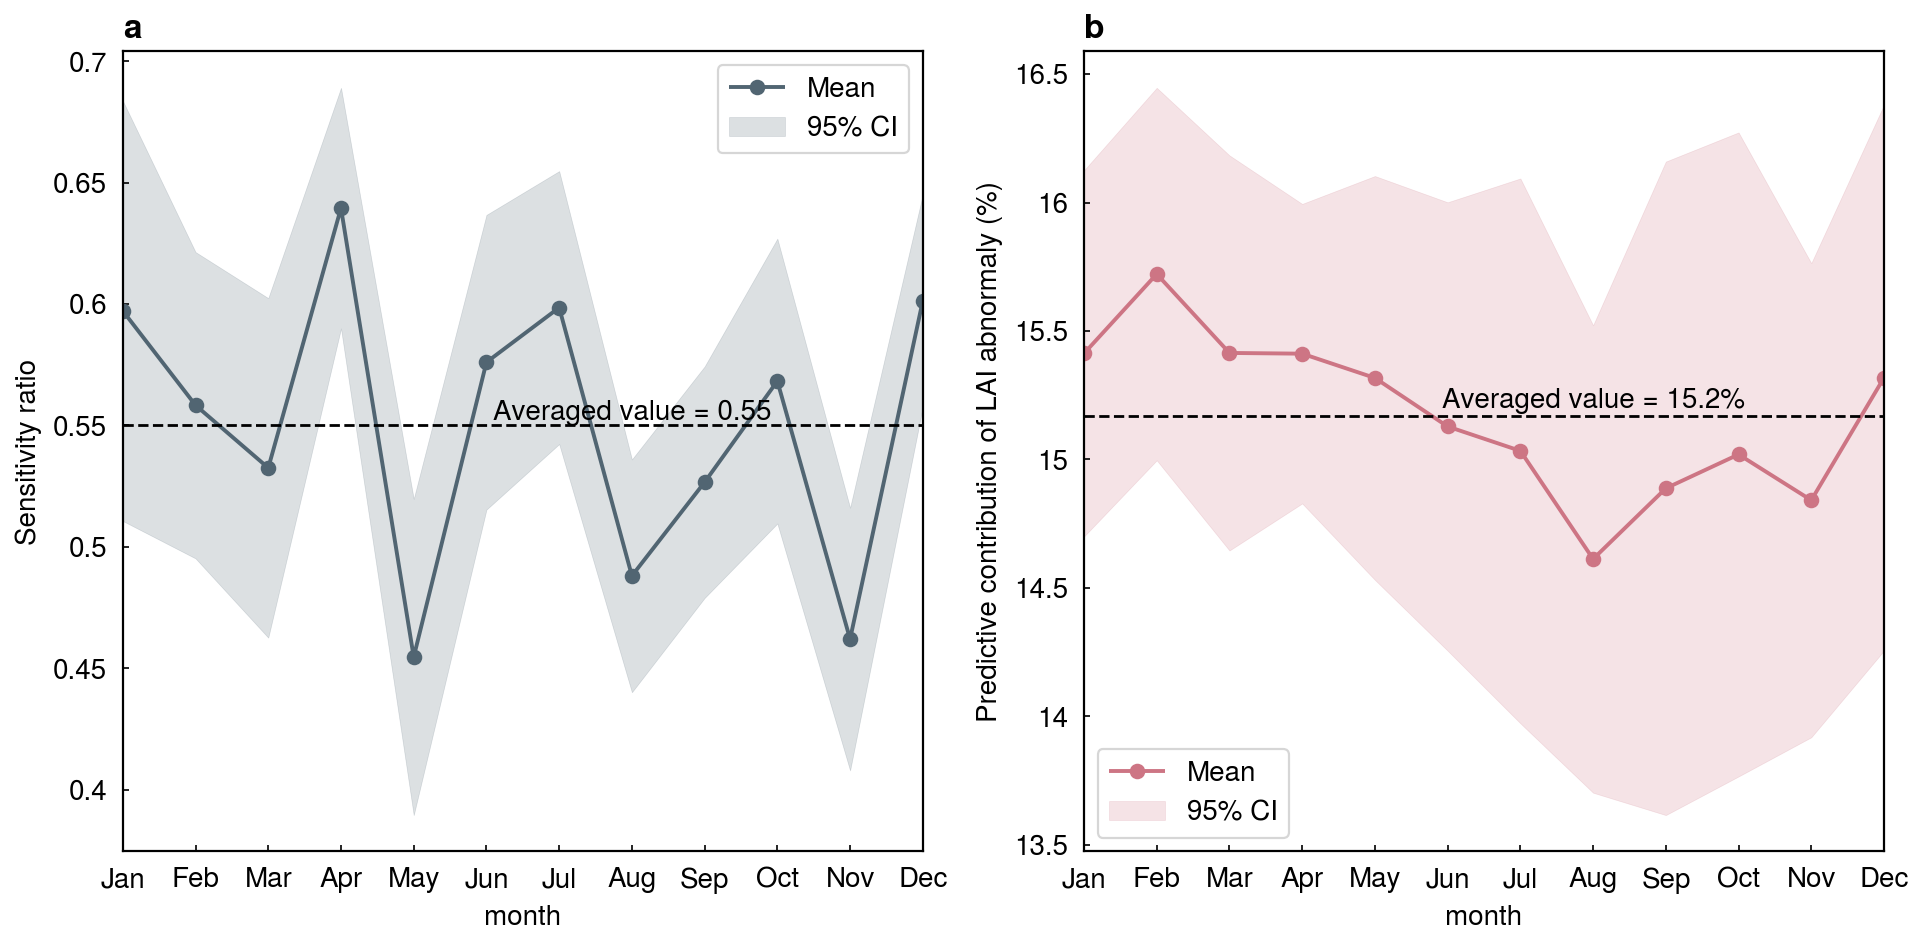

In [29]:
# Define subplot arrangement (single row with two subplots)
arrray = [  # the "picture" (0 == nothing, 1 == subplot A, 2 == subplot B, etc.)
    [1, 2]
]
# Create figure with specified parameters
fig = uplt.figure(refwidth=4, share=False, span=False, tight=True)
# Create subplots with specified layout parameters
axs = fig.subplots(arrray, abc=True, width_ratios=[1, 1], height_ratios=[1])

# Define month names for x-axis labels
months = monthly_stats.index
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
              'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# First subplot: Sensitivity ratio
ax3 = axs[0]
# Plot mean sensitivity ratio with markers
ax3.plot(np.array(months), np.array(monthly_stats[('ratio', 'mean')]), 
        color='slate', marker='o', label='Mean')

# Add confidence interval shading
ax3.fill_between(months,
                monthly_stats[('ratio', 'mean')] - monthly_stats[('ratio', 'ci')],
                monthly_stats[('ratio', 'mean')] + monthly_stats[('ratio', 'ci')],
                color='slate', alpha=0.2, label='95% CI')

# Add horizontal reference line at y=0.55
ax3.axhline(y=0.55, color='k', linestyle='--', linewidth=1)
# Add text annotation for the reference line
ax3.text(8, 0.55, 'Averaged value = 0.55', color='k', ha='center', va='bottom')

# Set y-axis label and configure x-axis ticks
ax3.set_ylabel('Sensitivity ratio')
ax3.set_xticks(months)
ax3.set_xticklabels(month_names)
ax3.legend(ncol=1)

############################
# Second subplot: LAI predictive contribution
ax4 = axs[1]
# Plot mean LAI contribution (converted to percentage) with markers
ax4.plot(np.array(months), np.array(monthly_stats[('value', 'mean')]*100),
        color='ugly pink', marker='o', label='Mean')

# Add confidence interval shading (converted to percentage)
ax4.fill_between(months,
                monthly_stats[('value', 'mean')]*100 - monthly_stats[('value', 'ci')]*100,
                monthly_stats[('value', 'mean')]*100 + monthly_stats[('value', 'ci')]*100,
                color='ugly pink', alpha=0.2, label='95% CI')

# Set y-axis label and configure x-axis ticks
ax4.set_ylabel('Predictive contribution of LAI abnormaly (%)')
ax4.set_xticks(months)
ax4.set_xticklabels(month_names)
ax4.legend(ncol=1)

# Add horizontal reference line at y=15.17
ax4.axhline(y=15.17, color='k', linestyle='--', linewidth=1)
# Add text annotation for the reference line
ax4.text(8, np.mean(np.array(monthly_stats[('value', 'mean')]*100)), 
         'Averaged value = 15.2%', color='k', ha='center', va='bottom')